In [111]:
import taichi as ti
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import inspect

sp.init_printing("mathjax")

# Finding the functions needed for RK4 simulation

In [112]:
R, m, g, t = sp.symbols("R m g t")

theta = sp.Function("\\theta")(t)
phi = sp.Function("\\phi")(t)

theta_d = sp.diff(theta, t)
phi_d = sp.diff(phi, t)

Defining the Lagrangian

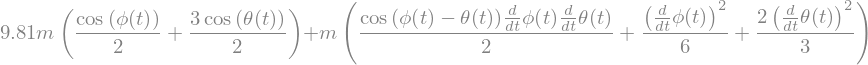

In [122]:
T = m*R*R * (sp.Rational(1,6)*theta_d**2 + sp.Rational(1,2)*theta_d**2 + sp.Rational(1,6)*phi_d**2 + sp.Rational(1,2)*theta_d*phi_d*sp.cos(theta-phi))
V = -R*m*g*(sp.Rational(3,2)*sp.cos(theta) + sp.Rational(1,2)*sp.cos(phi))
L = T - V

L

Finding the equations of motion for $\phi$ and $\theta$

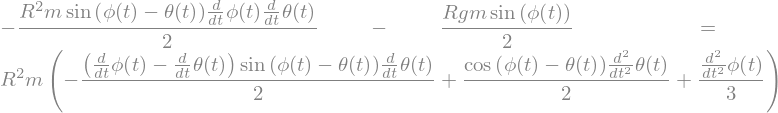

In [115]:
eq_motion_theta = sp.Equality(
    sp.diff(L, theta),
    sp.diff(
        sp.diff(L, theta_d),
        t
    )
)

eq_motion_phi = sp.Equality(
    sp.diff(L, phi),
    sp.diff(
        sp.diff(L, phi_d),
        t
    )
)

eq_motion_phi

Solving for the second derivatives of $\phi$ and $\theta$ in terms of the other variables

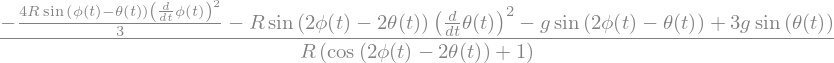

In [116]:
theta_dd = sp.solve(eq_motion_theta, sp.diff(theta_d, t))[0]
phi_dd = sp.solve(eq_motion_phi, sp.diff(phi_d, t))[0]


# equations for the second derivative of theta and phi as a function of theta, phi, and their derivatives
theta_dd_s = sp.solve(theta_dd.subs(phi_d.diff(t, 1), phi_dd), sp.diff(theta_d, t))[0].simplify()
phi_dd_s = sp.solve(phi_dd.subs(theta_d.diff(t, 1), theta_dd), sp.diff(phi_d, t))[0].simplify()

theta_dd_s

Compiling the above expressions into python functions which are quick to compute

In [117]:
tdd = sp.lambdify((theta, theta_d, phi, phi_d, R, g), theta_dd_s, "numpy")
pdd = sp.lambdify((theta, theta_d, phi, phi_d, R, g), phi_dd_s, "numpy")

In [118]:
print(inspect.getsource(tdd))

def _lambdifygenerated(_Dummy_219, _Dummy_217, _Dummy_220, _Dummy_218, R, g):
    return (_Dummy_217**2*R*sin(2*_Dummy_219 - 2*_Dummy_220) + (4/3)*_Dummy_218**2*R*sin(_Dummy_219 - _Dummy_220) + 3*g*sin(_Dummy_219) + g*sin(_Dummy_219 - 2*_Dummy_220))/(R*(cos(2*_Dummy_219 - 2*_Dummy_220) + 1))



# RK4 Simulation

Setting up

In [119]:
R = 1
g = 9.81

# initial condition
y = np.array([0.1, 0, 0.1, 0])

# function relating y to y'
def f(y, t):
    return np.array([
        y[1],
        tdd(y[0], y[1], y[2], y[3], R, g),
        y[3],
        pdd(y[0], y[1], y[2], y[3], R, g)
    ])

# time step between simulation frames
h = 0.001

# current time in the simulation
t = 0

Performing the simulation

In [120]:
past_positions = np.array(y)

for i in range(610):
    k1 = h*f(y, t)
    k2 = h*f(y + k1/2, t + h/2)
    k3 = h*f(y + k2/2, t + h/2)
    k4 = h*f(y + k3, t + h)

    y = y + k1/6 + k2/3 + k3/3 + k4/6

    past_positions = np.vstack([past_positions, y])

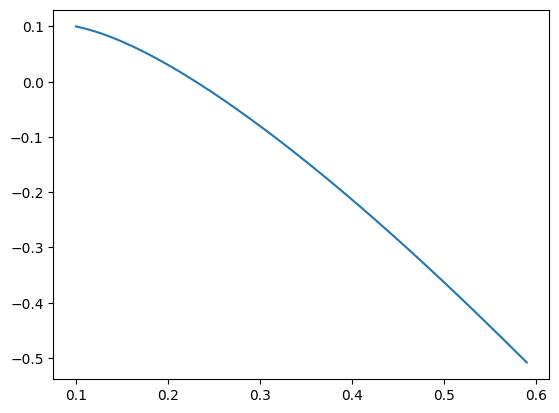

In [121]:
plt.plot(past_positions[:, 0], past_positions[:, 2])